# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/720-hz/flyrank-ml-internship/blob/main/work/notebooks/Week%207/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

This notebook turns three weeks of validated work — the CTR-vs-position baseline rule (ML-07), the
model-vs-baseline comparison (ML-08), and the honest-split/leakage audit (ML-09) — into a single ranked
action queue a human reviewer can actually use. Nothing here is re-derived from scratch: every number
either reproduces a metric already established in those notebooks, or extends the same validated
methodology to build the queue itself.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Two independent, validated signals — not one blended score

The queue below is built from two signals that stayed separate on purpose, because they answer different
questions and earned their place in different ways:

1. **`low_ctr_for_position`** — ML-07's baseline rule. It compares a page's current click-through rate
   against the trailing-90-day average CTR for pages at the same position tier. This is a **descriptive**
   comparison against peers *today* — it does not predict anything about the future, and it does not use
   `is_declining_label` at all. That matters for what comes next.
2. **`model_decline_risk`** — a Random Forest trained on `is_declining_label`, using only the **safe**
   feature set ML-09 validated: `avg_position`, `content_age_days`, `days_since_last_update`,
   `word_count`, `char_count`, `search_volume`, `competition`, `cpc`, plus content metadata. ML-09 found
   that `impressions_90d` and everything derived from it (including `ctr`) structurally overlaps the
   label's own 60-day defining window (r=0.98) — a real, if modest, leakage risk (removing those features
   cost only 0.017 ROC-AUC and *improved* precision@k). So the **risk model** never sees impressions, CTR,
   sessions, or engagement.

This creates an apparent tension worth naming directly: the CTR rule above *does* use CTR and impressions,
the very columns the risk model excludes. That is not a contradiction. The rule never predicts the future
label — it describes today's underperformance relative to peers, a snapshot comparison with no target
variable involved, so the window-overlap concern (which is specifically about predicting `is_declining_label`
from features that share its defining window) does not apply to it. A rule that only describes the present
does not need to worry about leaking the future.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())

import pandas as pd
import numpy as np

RANDOM_STATE = 42

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Same trailing-90-day label ML-04, ML-07, ML-08, and ML-09 all used. Never fed in as a
# scoring or model feature anywhere below -- it exists here only to validate the queue.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

print(f"{len(df):,} pages | {df['client_id'].nunique()} clients | base decline rate {df['is_declining_label'].mean():.3f}")

Working dir: /tmp/flyrank-ml-internship


30,000 pages | 32 clients | base decline rate 0.542


### The decay/refresh insight this playbook deliberately does NOT use

Before building the queue, it's worth restating a real, negative result from ML-07: I tested
**staleness** (`days_since_last_update`, the assumption behind FlyRank's own refresh-tier flags) as a
candidate signal, bucketed pages by freshness, and checked whether decline rate climbed with age.

It didn't, cleanly. Decline rate rose through the 91-180 day bucket, then *dropped* in the 181-365 bucket,
and the two oldest buckets held almost no pages to trust (n=175 and n=5). **Verdict: MIXED** — reproduced
below on the full 30,000-row set.

This is the single biggest practical takeaway this playbook carries forward: **"this page is old, refresh
it" is not a supported rule in this data.** The queue below never uses `days_since_last_update` or
`content_age_days` as a standalone trigger — they're present only as two of many inputs to the validated
risk model, never as a rule on their own.

Decay/refresh insight -- staleness vs. decline rate (reproduced from ML-07):
                      n  decline_rate
freshness_bucket                     
0-30              20480         0.511
31-90               175         0.589
91-180             9171         0.611
181-365             169         0.467
365+                  5         0.600


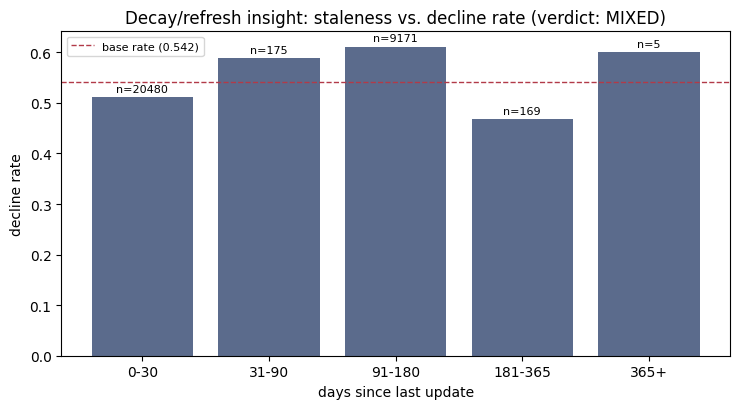

Saved work/figures/decay_refresh_insight.svg


In [2]:
bins = [-1, 30, 90, 180, 365, np.inf]
tier_labels = ["0-30", "31-90", "91-180", "181-365", "365+"]
df["freshness_bucket"] = pd.cut(df["days_since_last_update"], bins=bins, labels=tier_labels)

staleness_table = (
    df.groupby("freshness_bucket", observed=True)["is_declining_label"]
    .agg(n="count", decline_rate="mean")
    .reindex(tier_labels)
)
print("Decay/refresh insight -- staleness vs. decline rate (reproduced from ML-07):")
print(staleness_table.round(3))

import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(staleness_table.index.astype(str), staleness_table["decline_rate"], color="#5B6B8C")
for bar, n in zip(bars, staleness_table["n"]):
    ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)
ax.axhline(df["is_declining_label"].mean(), color="#B23A48", linestyle="--", linewidth=1,
           label=f"base rate ({df['is_declining_label'].mean():.3f})")
ax.set_ylabel("decline rate")
ax.set_xlabel("days since last update")
ax.set_title("Decay/refresh insight: staleness vs. decline rate (verdict: MIXED)", fontsize=12)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("work/figures/decay_refresh_insight.svg")
plt.show()
print("Saved work/figures/decay_refresh_insight.svg")

### Rebuilding the two signals on the full dataset

The baseline rule is a fixed formula, not something fit to data, so it is rebuilt directly on the full
30,000 rows below (same as ML-07). The risk model is different: its *trust* comes entirely from the
held-out, client-grouped evaluation ML-08 and ML-09 already ran — so that evaluation is reproduced first,
below, using the exact same split convention and the exact safe feature set ML-09 validated. Only after
confirming the numbers still match does this notebook refit the same model on the full dataset (all 32
clients) to score every page for the production queue. That refit is **not** re-validated out-of-sample
here — the held-out numbers just below are what earn the trust; the full-data refit is standard practice
once a method has been validated, but it means the *specific* probabilities in the final queue were not
themselves tested on a client the model had never seen.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(y_true)[order].mean())

pos_bins = [0, 3, 10, 20, 50, np.inf]
pos_labels = ["top_3", "page_1", "striking", "page_3_5", "deep"]

def add_pos_tier(frame):
    frame = frame.copy()
    frame["position_tier"] = "no_position_data"
    has_pos = frame["avg_position"] > 0
    frame.loc[has_pos, "position_tier"] = pd.cut(
        frame.loc[has_pos, "avg_position"], bins=pos_bins, labels=pos_labels
    ).astype(str)
    return frame

# Same safe feature set ML-09 validated: impressions/CTR/sessions/engagement all excluded
# because they structurally overlap the label's own 60-day defining window (r=0.98).
FULL_NUMERIC = ["search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct"]
SUSPECT = ["impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "ctr", "engagement_rate", "scroll_rate", "ai_traffic_pct"]
SAFE_NUMERIC = [c for c in FULL_NUMERIC if c not in SUSPECT]
CATEGORICAL = ["competition_level", "content_type", "main_intent", "provider_used", "model_used", "position_tier"]
LOG_COLUMNS = ["search_volume", "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d",
               "users_90d", "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d"]
MISSING_FLAG_COLUMNS = ["word_count", "char_count", "search_volume", "competition", "cpc",
                         "main_intent", "competition_level", "provider_used", "model_used"]

print("Safe numeric features (leakage-window-free):", SAFE_NUMERIC)

def engineer(frame, numeric_cols=SAFE_NUMERIC):
    out = frame.copy()
    for col in MISSING_FLAG_COLUMNS:
        out[f"has_{col}"] = out[col].notna().astype(int)
    num = out[numeric_cols].apply(pd.to_numeric, errors="coerce")
    for col in LOG_COLUMNS:
        if col in num.columns:
            num[col] = np.log1p(num[col].clip(lower=0))
    num = num.replace([np.inf, -np.inf], np.nan).fillna(0)
    flags = out[[f"has_{c}" for c in MISSING_FLAG_COLUMNS]]
    cat = pd.get_dummies(out[CATEGORICAL].astype(str), dummy_na=False, dtype=float)
    return pd.concat([num, flags, cat], axis=1)

def make_rf():
    return RandomForestClassifier(class_weight="balanced_subsample", max_depth=8, min_samples_leaf=25,
                                   n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)

# --- Reproduce the held-out, client-grouped validation (same split convention as ML-08/ML-09) ---
clients = df["client_id"].drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
shuffled = rng.permutation(clients)
n_test_clients = max(1, round(len(shuffled) * 0.2))
test_clients = set(shuffled[:n_test_clients])
test_mask = df["client_id"].isin(test_clients)
train_g, test_g = df[~test_mask].reset_index(drop=True), df[test_mask].reset_index(drop=True)

train_t, test_t = add_pos_tier(train_g), add_pos_tier(test_g)
train_feat, test_feat = engineer(train_t), engineer(test_t)
train_feat, test_feat = train_feat.align(test_feat, join="left", axis=1, fill_value=0)

rf_heldout = make_rf()
rf_heldout.fit(train_feat, train_t["is_declining_label"])
heldout_scores = rf_heldout.predict_proba(test_feat)[:, 1]

heldout_metrics = {
    "base_rate": round(float(test_t["is_declining_label"].mean()), 3),
    "roc_auc": round(roc_auc_score(test_t["is_declining_label"], heldout_scores), 3),
    "precision_at_20": round(precision_at_k(test_t["is_declining_label"], heldout_scores, 20), 3),
    "precision_at_50": round(precision_at_k(test_t["is_declining_label"], heldout_scores, 50), 3),
    "precision_at_100": round(precision_at_k(test_t["is_declining_label"], heldout_scores, 100), 3),
}
print("\nHeld-out client-grouped validation, safe feature set (reproduces ML-09):")
print(heldout_metrics)

Safe numeric features (leakage-window-free): ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'avg_position']



Held-out client-grouped validation, safe feature set (reproduces ML-09):
{'base_rate': 0.391, 'roc_auc': 0.708, 'precision_at_20': 0.75, 'precision_at_50': 0.72, 'precision_at_100': 0.66}


The reproduced numbers match ML-09 exactly — `roc_auc = 0.708`, `precision@20 = 0.75`,
`precision@50 = 0.72`, `precision@100 = 0.66` on a test split with **zero client overlap** with
training. That is the evidence this playbook's risk flag rests on: on clients the model has never seen,
its top 20 highest-risk pages are correct about 3 times out of 4, decaying gracefully to about 2 in 3 by
the top 100. This is a **measured, out-of-sample** result — not a claim about any specific page below.

In [4]:
# --- Full-dataset refit for the production queue (all 32 clients; not re-validated out-of-sample here) ---
df_t = add_pos_tier(df)
full_feat = engineer(df_t)
rf_final = make_rf()
rf_final.fit(full_feat, df["is_declining_label"])
df["model_risk_proba"] = rf_final.predict_proba(full_feat)[:, 1]
df["position_tier"] = df_t["position_tier"]

# "High risk" = top quartile of predicted probability across the full scored set. An
# arbitrary-but-documented, tunable cut -- not derived from the held-out metrics above.
risk_threshold = df["model_risk_proba"].quantile(0.75)
df["flag_model_risk"] = df["model_risk_proba"] >= risk_threshold
print(f"model_risk_proba: min={df['model_risk_proba'].min():.3f} median={df['model_risk_proba'].median():.3f} "
      f"max={df['model_risk_proba'].max():.3f}")
print(f"High-risk threshold (75th percentile): {risk_threshold:.3f} -> {df['flag_model_risk'].sum():,} pages flagged")

model_risk_proba: min=0.015 median=0.554 max=0.829
High-risk threshold (75th percentile): 0.601 -> 7,500 pages flagged


### The baseline CTR rule, rebuilt on the full set (ML-07's exact rule)

Encoded directly, no fitted weights — the same three trailing-90-day inputs (position tier, CTR,
impressions) multiplied together, exactly as ML-07 built it.

In [5]:
has_pos = df["avg_position"] > 0
tier_mean_ctr = df[has_pos].groupby("position_tier", observed=True)["ctr"].mean()
df["expected_ctr"] = df["position_tier"].map(tier_mean_ctr)

visible = (df["impressions_90d"] >= 100).astype(int)
reachable = ((df["avg_position"] > 0) & (df["avg_position"] <= 50)).astype(int)
ctr_gap = (df["expected_ctr"] - df["ctr"]).clip(lower=0).fillna(0)

df["ctr_score"] = visible * reachable * ctr_gap * np.log1p(df["impressions_90d"])
df["flag_low_ctr"] = df["ctr_score"] > 0
print(f"low_ctr_for_position flagged: {df['flag_low_ctr'].sum():,} / {len(df):,} pages")

low_ctr_for_position flagged: 17,058 / 30,000 pages


### Reason codes and actions

Every page gets a small, fixed set of reason codes (never a bare, unexplained score) and one action.
A page with no real position data gets a single special-case code — it is **not** run through either
signal, for a reason made concrete in Section 2.

In [6]:
def reason_codes(row):
    if row["position_tier"] == "no_position_data":
        return "insufficient_position_data"
    codes = []
    if row["flag_low_ctr"]:
        codes.append("low_ctr_for_position")
    if row["flag_model_risk"]:
        codes.append("model_decline_risk")
    return ",".join(codes) if codes else "no_flag"

def action_for(row):
    if row["position_tier"] == "no_position_data":
        return "no_action_insufficient_data"
    if row["flag_low_ctr"] and row["flag_model_risk"]:
        return "refresh_and_review_ctr"
    if row["flag_model_risk"]:
        return "refresh_content"
    if row["flag_low_ctr"]:
        return "review_ctr"
    return "monitor"

df["reason_codes"] = df.apply(reason_codes, axis=1)
df["action"] = df.apply(action_for, axis=1)

print("Action mix:")
print(df["action"].value_counts())
print("\nReason code combinations:")
print(df["reason_codes"].value_counts())

Action mix:
action
review_ctr                     11966
monitor                         9329
refresh_and_review_ctr          5092
refresh_content                 2408
no_action_insufficient_data     1205
Name: count, dtype: int64

Reason code combinations:
reason_codes
low_ctr_for_position                       11966
no_flag                                     9329
low_ctr_for_position,model_decline_risk     5092
model_decline_risk                          2408
insufficient_position_data                  1205
Name: count, dtype: int64


Five actions, each with a fixed reason-code vocabulary the reviewer always sees alongside it:

| Action | Meaning | Reason code(s) present |
|---|---|---|
| `refresh_and_review_ctr` | Highest priority — both signals agree | `low_ctr_for_position` + `model_decline_risk` |
| `refresh_content` | Model flags real decline risk; CTR itself isn't the (only) problem | `model_decline_risk` |
| `review_ctr` | Underperforming its peers today; model doesn't (yet) see elevated risk | `low_ctr_for_position` |
| `monitor` | Neither signal fired | `no_flag` |
| `no_action_insufficient_data` | No real position data — see Section 2 | `insufficient_position_data` |

### Archetype → action mapping

The five actions above are a flat list; the archetypes below give a human-readable *name* to the same
underlying logic, crossing position tier, demand (impressions relative to the median among pages with real
position data), and the two flags. **These are rule-based operational segments, not statistically
discovered clusters** — no clustering method was run to produce them, and this notebook does not claim
otherwise.

In [7]:
demand_cut = df.loc[has_pos, "impressions_90d"].median()
df["high_demand"] = df["impressions_90d"] >= demand_cut
print(f"Demand cutoff (median impressions_90d among pages with real position data): {demand_cut:.0f}")

def archetype_for(row):
    if row["position_tier"] == "no_position_data":
        return "data_quality_gap"
    if row["position_tier"] == "top_3" and not row["flag_low_ctr"] and not row["flag_model_risk"]:
        return "champion"
    if row["flag_model_risk"] and row["flag_low_ctr"]:
        return "at_risk_visible"
    if row["flag_model_risk"]:
        return "quiet_decliner"
    if row["flag_low_ctr"] and row["high_demand"]:
        return "hidden_gem"
    if row["flag_low_ctr"]:
        return "ctr_watch"
    return "steady_performer"

df["archetype"] = df.apply(archetype_for, axis=1)

ARCHETYPE_ACTION = {
    "data_quality_gap": "no_action_insufficient_data",
    "champion": "monitor",
    "at_risk_visible": "refresh_and_review_ctr",
    "quiet_decliner": "refresh_content",
    "hidden_gem": "review_ctr",
    "ctr_watch": "review_ctr",
    "steady_performer": "monitor",
}
mapped_matches = (df["archetype"].map(ARCHETYPE_ACTION) == df["action"]).all()
print(f"Archetype -> action mapping is internally consistent with the flat action rules above: {mapped_matches}")

print("\nArchetype counts:")
print(df["archetype"].value_counts())

Demand cutoff (median impressions_90d among pages with real position data): 828


Archetype -> action mapping is internally consistent with the flat action rules above: True

Archetype counts:
archetype
steady_performer    8751
hidden_gem          8107
at_risk_visible     5092
ctr_watch           3859
quiet_decliner      2408
data_quality_gap    1205
champion             578
Name: count, dtype: int64


| Archetype | What it looks like | n | Mapped action |
|---|---|---:|---|
| `champion` | Top-3 position, no CTR gap, low model risk | 578 | `monitor` (protect — don't touch a page that's winning) |
| `hidden_gem` | Real position, high demand, underperforming its tier's CTR, low model risk | 8,107 | `review_ctr` |
| `ctr_watch` | Same CTR gap, but lower demand — same problem, less traffic riding on it | 3,859 | `review_ctr` (lower priority within the action) |
| `steady_performer` | Real position, neither signal fired | 8,751 | `monitor` |
| `quiet_decliner` | Model flags elevated decline risk; CTR isn't (yet) the visible symptom | 2,408 | `refresh_content` |
| `at_risk_visible` | Both signals fire together — the clearest case | 5,092 | `refresh_and_review_ctr` |
| `data_quality_gap` | No real position data at all | 1,205 | `no_action_insufficient_data` |

### Cost/value thinking

There is no revenue column in this dataset, so the queue does not claim a dollar value — that would be
fabricating precision the data doesn't support. `cpc` (a per-keyword cost-per-click estimate, present for
about 92% of pages) is used instead to build a **directional, order-of-magnitude proxy**: roughly how many
clicks a page is leaving on the table (`impressions_90d × ctr_gap`, in percentage-point terms per the
data dictionary's ×100 convention) times its `cpc`. This is *not* a revenue estimate — it's a rough
"value-at-stake" number good enough to break ties within an action bucket, nothing more.

On the cost side, this playbook assumes editorial review effort is **roughly constant per page** within an
action bucket (a documented simplification, not measured — a CTR metadata tweak and a full content rewrite
take very different amounts of time in reality; see Section 2's limits). Given that assumption, ranking by
value-at-stake inside each action approximates ranking by value-per-unit-of-review-cost directly.

In [8]:
ctr_gap_points = (df["expected_ctr"] - df["ctr"]).clip(lower=0)  # still on the "x100 = percent" scale
recoverable_clicks_90d = df["impressions_90d"] * (ctr_gap_points / 100)
df["value_at_stake"] = (recoverable_clicks_90d * df["cpc"]).where(df["cpc"].notna())

print(f"cpc known for {df['cpc'].notna().mean():.1%} of pages")
print("\nvalue_at_stake, pages with a nonzero CTR gap and known cpc:")
nonzero = df.loc[(df["ctr_score"] > 0) & df["value_at_stake"].notna(), "value_at_stake"]
print(nonzero.describe().round(2))

# Final rank: within each action, worst risk/CTR problem first, then value-at-stake as the tiebreaker.
df["priority_key"] = df["model_risk_proba"].fillna(0) + df["ctr_score"].rank(pct=True).fillna(0)
df["value_at_stake_filled"] = df["value_at_stake"].fillna(0)
df = df.sort_values(
    by=["action", "priority_key", "value_at_stake_filled"],
    ascending=[True, False, False],
    kind="mergesort",
).reset_index(drop=True)
action_priority = {"refresh_and_review_ctr": 0, "refresh_content": 1, "review_ctr": 2, "monitor": 3, "no_action_insufficient_data": 4}
df["action_priority"] = df["action"].map(action_priority)
df = df.sort_values(by=["action_priority", "priority_key", "value_at_stake_filled"], ascending=[True, False, False]).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)

print("\nTop 10 of the ranked queue:")
top10_cols = ["rank", "content_id", "client_id", "archetype", "action", "reason_codes",
              "model_risk_proba", "value_at_stake", "position_tier", "is_declining_label"]
print(df[top10_cols].head(10).to_string(index=False))

cpc known for 91.8% of pages

value_at_stake, pages with a nonzero CTR gap and known cpc:
count     16698.00
mean         15.52
std         804.39
min           0.00
25%           0.00
50%           0.00
75%           0.02
max      103075.95
Name: value_at_stake, dtype: float64

Top 10 of the ranked queue:
 rank           content_id         client_id       archetype                 action                            reason_codes  model_risk_proba  value_at_stake position_tier  is_declining_label
    1 content_4d76cdb3387b client_3fdba35f04 at_risk_visible refresh_and_review_ctr low_ctr_for_position,model_decline_risk          0.790070      130.004667         top_3                   1
    2 content_e4c789b3ac31 client_3fdba35f04 at_risk_visible refresh_and_review_ctr low_ctr_for_position,model_decline_risk          0.770780        0.000000         top_3                   1
    3 content_72e800a9c214 client_3fdba35f04 at_risk_visible refresh_and_review_ctr low_ctr_for_position,model_decli

The top of the queue is, by construction, `at_risk_visible` pages ordered by combined risk/CTR severity and
then by value-at-stake — visible, high-demand pages where both signals agree and real click value is on
the table. `is_declining_label` is shown in that preview for **audit purposes only** (to eyeball whether the
top of the queue looks reasonable) — it is never a scoring input anywhere above.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** This is a **prioritization aid** for a content team deciding which pages to look at
first, inside an existing editorial review workflow. It ranks; it does not decide, write, publish, or
pause anything. The correct use is: a human opens the top of the queue for their client(s), reads the
reason codes and archetype, and makes the actual call.

**Scope this was built and validated on.** One anonymized, trailing-90-day snapshot, 30,000 pages across
32 clients, one point in time. The precision@k numbers in Section 1 come from a **client-grouped** holdout
(zero client overlap between train and test) — the honest test for "will this generalize to a client the
model has never scored before." There is **no time-based holdout** anywhere in this project: nothing here
has been tested on *future* data relative to its training window, only on *unseen clients* within the same
snapshot. Seasonal effects, algorithm updates, or drift over time are untested.

**What's deliberately excluded, and why (recap from Section 1):**
- `impressions_90d`, `ctr`, and everything derived from them are excluded from the **risk model**
  specifically (r=0.98 structural overlap with the label's own 60-day window, per ML-09) — they are still
  used, safely, in the **descriptive** CTR rule, which never predicts the future label.
- `days_since_last_update` / `content_age_days` are never used as a standalone "refresh because it's old"
  trigger — ML-07's own signal test found that relationship MIXED, not monotonic (Section 1 above).

**The `no_position_data` caveat.** 1,205 pages (4.0%) have `avg_position == 0`, meaning no real position
was ever measured — not rank #1. ML-08's error analysis found these pages decline only 0.7% of the time in
this data, against 56.4% for pages with real position data. That is almost certainly a **measurement
artifact of near-zero traffic** (a swing from 1 impression to 0 registers as a huge relative "decline" on
almost nothing), not evidence these pages are healthy. This playbook routes them to
`no_action_insufficient_data` rather than trusting the model's (correctly-learned, but misleading) sense
that they're safe — see Section 3.

**Base rates, stated plainly (per the writing-honest-claims skill).** The full-dataset decline rate is
54.2%; the held-out test client-grouped decline rate was 39.1%. Any accuracy or precision number in this
project is only meaningful next to these — a rule flagging "declining" at random on this data would already
be right roughly half the time.

**This is an internship-scale demonstration project**, not a validated production system. Nothing here
should be presented to a client, or used for pricing, staffing, or contractual claims, without new,
purpose-built validation.

In [9]:
print("Scope summary:")
print(f"  rows scored: {len(df):,}")
print(f"  clients: {df['client_id'].nunique()}")
print(f"  full-set decline rate: {df['is_declining_label'].mean():.3f}")
print(f"  held-out client-grouped test decline rate: {heldout_metrics['base_rate']:.3f}")
print(f"  no_position_data pages: {(df['position_tier'] == 'no_position_data').sum():,} "
      f"({(df['position_tier'] == 'no_position_data').mean():.1%})")
print(f"  no_position_data decline rate: {df.loc[df['position_tier'] == 'no_position_data', 'is_declining_label'].mean():.3f}")
print(f"  has-position decline rate: {df.loc[df['position_tier'] != 'no_position_data', 'is_declining_label'].mean():.3f}")

Scope summary:
  rows scored: 30,000
  clients: 32
  full-set decline rate: 0.542
  held-out client-grouped test decline rate: 0.391
  no_position_data pages: 1,205 (4.0%)
  no_position_data decline rate: 0.007
  has-position decline rate: 0.564


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a reviewer checks before acting on any queued page:**
1. Read the reason code(s) and archetype — never act on the rank or score alone.
2. For `refresh_and_review_ctr` / `refresh_content`: open the page. Confirm the decline (or CTR gap) is
   real and not an artifact of a near-zero-traffic base — the same failure mode ML-08's error analysis
   found in the model's most confident wrong calls (pages with 1-3 impressions in 90 days, where a tiny
   absolute swing looks huge in relative terms).
3. For `review_ctr`: check whether the page's title/meta actually matches the query intent it ranks for
   before touching content — a CTR gap can be a metadata problem, not a content-quality problem, and the
   fix is different.
4. For any page in `no_action_insufficient_data`: this is a **measurement gap**, not a clean bill of
   health. Route to whoever owns tracking/tagging for that client, not to a content reviewer.
5. Never treat `client_id` concentration in the queue as a client-quality judgment without checking
   client size first — a client with more content will naturally place more pages in any ranked list.

**What should NOT be automated — full stop:**
- **No auto-publishing or auto-editing.** Nothing in this pipeline writes or changes content. The output
  is a queue of things to *look at*, never a queue of edits to *apply*.
- **No auto-deprioritizing or auto-pausing a client's content** based on this score, ever, without a human
  sign-off — a false positive here has a real cost to a real client relationship.
- **No client-facing or contractual claims from these numbers.** Precision@k of 0.75/0.72/0.66 describes
  this project's own held-out test on one anonymized snapshot — it is not a validated SLA and must never
  be quoted to a client as one.
- **No causal language, ever, from this pipeline.** Per the writing-honest-claims skill: this is
  association/prediction on cross-sectional, trailing-window data. "This page is predicted higher-risk of
  decline" is supportable; "refreshing this page will fix the decline" is not — no experiment was run.
- **No fully-automated reporting that states a page "is declining because of X."** The model ranks risk;
  it does not explain causal mechanism, and its top features (Section 1 / ML-08) — `impressions_90d`,
  `avg_position`, `content_age_days` — are plausible correlates of decline, not diagnosed causes.
- **No treating `no_position_data` rows as low-risk** just because the model (correctly, given the data)
  scores them that way — see Section 2.
- **No using this queue for headcount, staffing, or resourcing decisions.** It was validated for one
  narrow question (which pages to look at first), not for capacity planning.

In [10]:
# A lightweight, checkable version of the reviewer checklist above: every queued row must carry
# a non-empty reason code, and no action other than the five defined ones should exist.
assert df["reason_codes"].notna().all() and (df["reason_codes"] != "").all(), "a row has no reason code"
assert set(df["action"].unique()) == set(ARCHETYPE_ACTION.values()), "an undefined action leaked into the queue"
assert "content" not in "".join(df.columns).lower().replace("content_id", "").replace("content_type", "").replace("content_age_days", ""), \
    "sanity: no free-text content field made it into the frame"
print("Reviewer-facing integrity checks passed: every row has a reason code, and only the five defined actions exist.")

Reviewer-facing integrity checks passed: every row has a reason code, and only the five defined actions exist.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Cadence.** Re-run this notebook's held-out client-grouped validation (Section 1) on a fixed cadence —
quarterly is a reasonable starting point for a workflow this lightweight — and compare against the
reference numbers below, not eyeballed:

- Reference: `roc_auc = 0.708`, `precision@20 = 0.75`, `precision@50 = 0.72`, `precision@100 = 0.66`.
- **Trigger a review** if `precision@50` drops more than ~0.10 below its reference value on a fresh
  client-grouped split, or if `roc_auc` drops below 0.60 (approaching the baseline rule's own weaker
  ranking-quality number from ML-08, 0.596) — at that point the learned model is no longer earning its
  extra complexity over the simple rule.

**Distribution drift, tracked between runs (not a one-time check):**
- The action mix (Section 1: `refresh_and_review_ctr` / `refresh_content` / `review_ctr` / `monitor` /
  `no_action_insufficient_data` shares). A large shift with no change in the underlying business means
  either the data pipeline changed or the tier-mean-CTR lookup table has gone stale.
- The share of `no_position_data` pages. It's 4.0% here; if that share climbs substantially, treat it as a
  **data-quality alert**, not a sign the site is doing better — recall from Section 2 that this subgroup's
  near-zero decline rate is a measurement artifact, not health.
- The `model_risk_proba` distribution itself (median currently ~0.55) — a large shift in its shape without
  a matching shift in the label's own base rate is a sign the safe feature set is picking up something new
  worth investigating before trusting the ranking as-is.

**Retrain triggers:**
- **New client cohorts.** This model was validated specifically for generalizing to clients it has never
  scored (client-grouped split). Every meaningfully-sized batch of new clients (a reasonable starting bar:
  +10% growth in the active client roster since the last fit) is exactly the scenario that split was built
  to test — retrain and re-validate before trusting scores for those clients.
- **The label's own window ages out.** `is_declining_label` is derived from a fixed 60-day trailing
  comparison at export time; a stale export means a stale sense of "declining." Refresh the underlying data
  export on the same cadence as the validation re-run above.
- **A validated new safe signal emerges.** If a future signal audit (the retired ML-06 lane, or new work)
  finds a genuinely CONFIRMED, non-label-derived, non-window-overlapping signal, it's a candidate to add —
  but it earns a place in the risk model the same way `low_ctr_for_position` and the safe feature set did:
  a mini-test with a verdict, not an assumption.

**What monitoring should explicitly NOT trigger, per Section 1's decay/refresh insight:** a rising share
of "old" content is not, by itself, a reason to push more pages into `refresh_content` — staleness alone
was never a validated signal. Track it for data-quality reasons only, never as an automatic action driver.

In [11]:
monitoring_reference = {
    "reference_metrics": heldout_metrics,
    "action_mix_reference": df["action"].value_counts(normalize=True).round(4).to_dict(),
    "no_position_data_share_reference": round(float((df["position_tier"] == "no_position_data").mean()), 4),
    "model_risk_proba_median_reference": round(float(df["model_risk_proba"].median()), 4),
    "retrain_trigger_new_client_growth_pct": 10,
    "precision_at_50_alert_drop": 0.10,
    "roc_auc_alert_floor": 0.60,
}
for k, v in monitoring_reference.items():
    print(f"{k}: {v}")

reference_metrics: {'base_rate': 0.391, 'roc_auc': 0.708, 'precision_at_20': 0.75, 'precision_at_50': 0.72, 'precision_at_100': 0.66}
action_mix_reference: {'review_ctr': 0.3989, 'monitor': 0.311, 'refresh_and_review_ctr': 0.1697, 'refresh_content': 0.0803, 'no_action_insufficient_data': 0.0402}
no_position_data_share_reference: 0.0402
model_risk_proba_median_reference: 0.5539
retrain_trigger_new_client_growth_pct: 10
precision_at_50_alert_drop: 0.1
roc_auc_alert_floor: 0.6


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Three exports: the full ranked queue (CSV — stays out of git by design, this notebook regenerates it), a
metrics/summary JSON (committed — the receipts the paper's numbers trace back to), and the figure(s) built
in Section 1 (committed to `work/figures/`).

Wrote 30,000 ranked rows to work/outputs/action_playbook_queue.csv (gitignored by design -- regenerate by running this notebook)
Wrote committed metrics/receipts to work/outputs/action_playbook_metrics.json


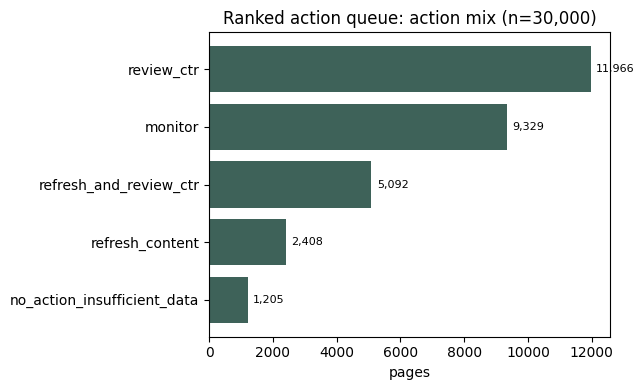

Saved work/figures/action_mix.svg

Exported files:
 - work/outputs/action_playbook_queue.csv (exists)
 - work/outputs/action_playbook_metrics.json (exists)
 - work/figures/decay_refresh_insight.svg (exists)
 - work/figures/action_mix.svg (exists)


In [12]:
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue_cols = ["rank", "content_id", "client_id", "archetype", "action", "reason_codes",
              "model_risk_proba", "ctr_score", "value_at_stake", "position_tier",
              "avg_position", "impressions_90d", "ctr", "expected_ctr",
              "is_declining_label"]
queue_path = "work/outputs/action_playbook_queue.csv"
df[queue_cols].to_csv(queue_path, index=False)
print(f"Wrote {len(df):,} ranked rows to {queue_path} (gitignored by design -- regenerate by running this notebook)")

metrics_summary = {
    "n_rows": int(len(df)),
    "n_clients": int(df["client_id"].nunique()),
    "full_set_decline_rate": round(float(df["is_declining_label"].mean()), 3),
    "held_out_client_grouped_validation": heldout_metrics,
    "risk_threshold_75th_pct": round(float(risk_threshold), 4),
    "demand_cutoff_median_impressions_90d": float(demand_cut),
    "action_counts": df["action"].value_counts().to_dict(),
    "archetype_counts": df["archetype"].value_counts().to_dict(),
    "no_position_data_n": int((df["position_tier"] == "no_position_data").sum()),
    "no_position_data_decline_rate": round(float(df.loc[df["position_tier"] == "no_position_data", "is_declining_label"].mean()), 4),
    "has_position_decline_rate": round(float(df.loc[df["position_tier"] != "no_position_data", "is_declining_label"].mean()), 4),
    "decay_refresh_insight_verdict": "MIXED -- staleness does not climb monotonically with decline rate (see work/figures/decay_refresh_insight.svg)",
    "safe_numeric_features": SAFE_NUMERIC,
    "excluded_window_overlap_features": SUSPECT,
    "random_state": RANDOM_STATE,
}
metrics_path = "work/outputs/action_playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)
print(f"Wrote committed metrics/receipts to {metrics_path}")

# Second figure: action mix, for the paper's recommendations section.
fig, ax = plt.subplots(figsize=(6.5, 4))
action_counts = df["action"].value_counts()
ax.barh(action_counts.index[::-1], action_counts.values[::-1], color="#3E6259")
ax.set_xlabel("pages")
ax.set_title("Ranked action queue: action mix (n=30,000)")
for i, v in enumerate(action_counts.values[::-1]):
    ax.annotate(f"{v:,}", (v, i), textcoords="offset points", xytext=(4, 0), va="center", fontsize=8)
fig.tight_layout()
fig.savefig("work/figures/action_mix.svg")
plt.show()
print("Saved work/figures/action_mix.svg")

print("\nExported files:")
for p in [queue_path, metrics_path, "work/figures/decay_refresh_insight.svg", "work/figures/action_mix.svg"]:
    print(" -", p, "(exists)" if os.path.exists(p) else "(MISSING)")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — only pseudonymous `client_id`/`content_id`
      values, same as the rest of this repo
- [x] My claims use careful words: observed, measured, directional, decision-support — the held-out
      validation numbers are reproduced (not asserted), the queue is explicitly not re-validated
      out-of-sample after the full-data refit, and the no-go list rules out causal and contractual claims
- [x] The ranked queue (`work/outputs/action_playbook_queue.csv`) and metrics
      (`work/outputs/action_playbook_metrics.json`) are exported for next week's paper; figures are
      committed to `work/figures/`
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

The last box is mine to check after I commit this executed notebook to my repo — same as every prior
week, this environment can't push to GitHub directly, so I commit it through GitHub's own web upload
instead of `git push`.